In [0]:
import pandas as pd
import matplotlib.pyplot as plt

In [0]:
universe_ticker_price = pd.read_csv("universe_ticker_price.csv")
universe_ticker_price.head()

# Assume df['date'] contains strings like '1995-01-09' and '2025-12-26 00:00:00'
universe_ticker_price['date'] = pd.to_datetime(universe_ticker_price['date'], errors='coerce')

# If you want *date only* (no time), normalize to midnight:
universe_ticker_price['date'] = universe_ticker_price['date'].dt.date

universe_ticker_price.head()

,symbol,date,open,high,low,close,adjusted_close,volume
0,FL.us,1995-01-03,15.250,16.125,15.250,15.375,8.4459,1116000
1,FL.us,1995-01-04,15.500,16.125,15.500,16.125,8.8579,1226500
2,FL.us,1995-01-05,16.125,16.750,16.125,16.750,9.2013,1122300
3,FL.us,1995-01-06,16.750,17.000,16.500,16.625,9.1326,733900
4,FL.us,1995-01-09,16.750,16.750,16.125,16.250,8.9266,728700


In [0]:
current_sp500_tickers = pd.read_csv("current_sp500_tickers.csv")['symbol'].tolist()
current_sp500_tickers = [ticker + '.us' for ticker in current_sp500_tickers]
current_sp500_tickers

['MMM.us',
 'AOS.us',
 'ABT.us',
 'ABBV.us',
 'ACN.us',
 'ADBE.us',
 'AMD.us',
 'AES.us',
 'AFL.us',
 'A.us',
 'APD.us',
 'ABNB.us',
 'AKAM.us',
 'ALB.us',
 'ARE.us',
 'ALGN.us',
 'ALLE.us',
 'LNT.us',
 'ALL.us',
 'GOOGL.us',
 'GOOG.us',
 'MO.us',
 'AMZN.us',
 'AMCR.us',
 'AEE.us',
 'AEP.us',
 'AXP.us',
 'AIG.us',
 'AMT.us',
 'AWK.us',
 'AMP.us',
 'AME.us',
 'AMGN.us',
 'APH.us',
 'ADI.us',
 'AON.us',
 'APA.us',
 'APO.us',
 'AAPL.us',
 'AMAT.us',
 'APP.us',
 'APTV.us',
 'ACGL.us',
 'ADM.us',
 'ARES.us',
 'ANET.us',
 'AJG.us',
 'AIZ.us',
 'T.us',
 'ATO.us',
 'ADSK.us',
 'ADP.us',
 'AZO.us',
 'AVB.us',
 'AVY.us',
 'AXON.us',
 'BKR.us',
 'BALL.us',
 'BAC.us',
 'BAX.us',
 'BDX.us',
 'BRK.B.us',
 'BBY.us',
 'TECH.us',
 'BIIB.us',
 'BLK.us',
 'BX.us',
 'XYZ.us',
 'BK.us',
 'BA.us',
 'BKNG.us',
 'BSX.us',
 'BMY.us',
 'AVGO.us',
 'BR.us',
 'BRO.us',
 'BF.B.us',
 'BLDR.us',
 'BG.us',
 'BXP.us',
 'CHRW.us',
 'CDNS.us',
 'CPT.us',
 'CPB.us',
 'COF.us',
 'CAH.us',
 'CCL.us',
 'CARR.us',
 'CVNA.us'

In [0]:
# import pandas as pd

# Assuming df is your dataframe
# 1. Group by symbol and calculate the percentage change on adjusted_price
universe_ticker_price['return'] = universe_ticker_price.groupby('symbol')['adjusted_close'].pct_change()

# 2. Filter for returns larger than 100% (represented as > 1.0)
high_returns = universe_ticker_price[universe_ticker_price['return'] > 0.8][['symbol', 'date', 'return']]
low_returns = universe_ticker_price[universe_ticker_price['return'] < -0.8][['symbol', 'date', 'return']]

print(high_returns['symbol'].unique())

print(low_returns['symbol'].unique())


['FL.us' 'LXK.us' 'ABMD.us' 'ESRX.us' 'PBI.us' 'FLIR.us' 'VAR.us' 'RSH.us'
 'EP.us' 'ANR.us' 'CMCSK.us' 'CSC.us' 'FII.us' 'CERN.us' 'LLL.us' 'DNR.us'
 'PLL.us' 'AN.us' 'STR.us' 'WLTW.us' 'SIVB.us' 'RX.us' 'CVC.us' 'TIE.us'
 'TWX.us' 'RHT.us' 'BMS.us' 'STJ.us' 'WIN.us' 'GR.us' 'WST.us' 'NFX.us'
 'SGP.us' 'GLK.us' 'SWY.us' 'MRO.us' 'HNZ.us' 'XL.us' 'CPWR.us' 'PCP.us'
 'SVU.us' 'LUMN.us' 'MWW.us' 'NCC.us' 'KSE.us' 'JWN.us' 'BCR.us' 'MNK.us'
 'SLE.us' 'SLR.us' 'ATVI.us' 'AVP.us' 'BRCM.us' 'PBCT.us' 'FTR.us'
 'CFC.us' 'LVLT.us' 'CTXS.us' 'GGP.us' 'X.us' 'STI.us' 'HAR.us' 'AYE.us'
 'LVS.us' 'CTX.us' 'ENDP.us' 'LLTC.us' 'GME.us' 'NKTR.us' 'RRD.us'
 'SWN.us' 'GNW.us' 'MI.us' 'SBNY.us' 'ANDV.us' 'EK.us' 'MDP.us' 'APC.us'
 'EXPE.us' 'SRCL.us' 'CHK.us' 'GMCR.us' 'DASH.us' 'HIG.us' 'DWDP.us'
 'FOSL.us' 'AET.us' 'GPS.us' 'NCR.us' 'YHOO.us' 'RAI.us' 'LM.us' 'BKNG.us'
 'CBE.us' 'SAI.us' 'MBI.us' 'WMB.us' 'WFR.us' 'FRE.us' 'ABK.us' 'MS.us']
['LIFE.us' 'MIL.us' 'RSH.us' 'EP.us' 'FRX.us' 'CERN.us' 'RX.u

In [0]:
# universe_ticker_price[universe_ticker_price['symbol'] == 'ABK.us']
print(len(high_returns['symbol'].unique()))
print(len(low_returns['symbol'].unique()))


101
38


In [0]:
universe_ticker_price2 = universe_ticker_price[~universe_ticker_price['symbol'].isin(high_returns['symbol'].unique().tolist())]
universe_ticker_price2 = universe_ticker_price2[~universe_ticker_price2['symbol'].isin(low_returns['symbol'].unique().tolist())]
universe_ticker_price2.head()

,symbol,date,open,high,low,close,adjusted_close,volume,return
10761,CVNA.us,2017-04-28,13.50,13.94,10.70,11.10,11.10,11297800,NaN
10762,CVNA.us,2017-05-01,11.60,11.73,10.70,10.77,10.77,1291300,-0.029730
10763,CVNA.us,2017-05-02,10.95,10.95,10.00,10.10,10.10,991500,-0.062210
10764,CVNA.us,2017-05-03,10.18,10.18,8.18,8.72,8.72,3356500,-0.136634
10765,CVNA.us,2017-05-04,8.59,10.04,8.14,9.98,9.98,1840200,0.144495


In [0]:
len(universe_ticker_price2['symbol'].unique())

737

In [0]:
def plot_price_history(df):
    """
    Plots the 'adjusted_price' column from a DataFrame with a DateTimeIndex.

    Args:
        df (pd.DataFrame): DataFrame with 'Date' as index and 'adjusted_price' column.
    """
    
    # 1. Data Validation and Preparation
    if not isinstance(df.index, pd.DatetimeIndex):
        print("Error: DataFrame index is not a DatetimeIndex. Attempting conversion.")
        df.index = pd.to_datetime(df.index)
    
    if 'adjusted_close' not in df.columns:
        print("Error: 'adjusted_price' column not found.")
        return

    # Ensure data is sorted by date for correct plotting
    df = df.sort_index()

    # 2. Plotting using pandas' built-in plot function
    plt.figure(figsize=(12, 6))
    
    # The index (Date) is automatically used for the X-axis
    # The 'adjusted_price' column is used for the Y-axis
    df['adjusted_close'].plot(color='blue', linewidth=1.5)

    # 3. Customization
    plt.title('Stock Adjusted Price History', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Adjusted Price (USD)')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Ensure optimal date formatting on the X-axis
    plt.tight_layout()
    plt.show()
# plot_price_history(universe_ticker_price[universe_ticker_price['symbol'] == 'LIFE.us'])


In [0]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Sequence

def compute_cumulative_returns_dynamic_rest(
    df: pd.DataFrame,
    start_date: str = "2010-01-01",
    end_date: str = "2025-12-31",
    main_tickers: Sequence[str] = ("QQQ.us", "SPY.us"),
    additional_tickers: Sequence[str] = current_sp500_tickers,
    price_col: str = "adjusted_close",
    symbol_col: str = "symbol",
    date_col: str = "date",
    plot: bool = True,
) -> pd.DataFrame:
    """
    Compute cumulative growth of $1 for:
      - QQQ.us and SPY.us (if present in data)
      - Dynamic equal-weight 'Rest' portfolio of the other tickers

    Assumptions / Logic:
    - Daily rebalancing among *active* rest tickers (equal-weight).
    - IPO: when a ticker first has a price, it receives equal weight from that day onward.
    - Delist: when a ticker no longer has a price, its weight is redistributed among remaining actives next day.
    - Missing returns are treated as 0 (no contribution) and excluded from the equal-weight count using an active mask.

    Parameters
    ----------
    df : DataFrame with columns [symbol, date, adjusted_close]
    start_date, end_date : inclusive date bounds (YYYY-MM-DD)
    main_tickers : benchmark tickers to show individually
    price_col, symbol_col, date_col : column names in df
    plot : whether to display a comparison plot

    Returns
    -------
    cum_df
    """

    # 1) Robust date parsing & filtering
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    if df[date_col].isna().all():
        raise ValueError("Failed to parse any dates in df[date].")

    start_ts = pd.to_datetime(start_date)
    end_ts   = pd.to_datetime(end_date)

    # Filter to the requested range
    mask_range = (df[date_col] >= start_ts) & (df[date_col] <= end_ts)
    df = df.loc[mask_range]

    # Basic checks
    required_cols = {symbol_col, date_col, price_col}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in input DataFrame: {missing}")

    if df.empty:
        raise ValueError("No rows remain after date filtering. Check your bounds and input data.")

    # 2) Pivot to wide price matrix: rows=dates, cols=symbols
    prices = (
        df.pivot(index=date_col, columns=symbol_col, values=price_col)
          .sort_index()
    )

    # 3) Identify active tickers each day (non-NaN price)
    active_mask = prices.notna().astype(float)

    # 4) Daily returns (vectorized). Treat NaNs as 0 to avoid breaking the sum.
    #    If a ticker is newly active (first day), its pct_change is NaN -> we set to 0 (no jump on entry day).
    daily_ret = prices.pct_change().fillna(0.0)

    # 5) Split into benchmarks and rest
    main_tickers_present = [t for t in main_tickers if t in prices.columns]
    rest_tickers = [t for t in prices.columns if t not in main_tickers_present]
    additional_tickers = [t for t in additional_tickers if t in prices.columns]

    # 6) Dynamic equal-weight daily return for Rest
    if rest_tickers:
        rest_ret = daily_ret[rest_tickers]
        rest_mask = active_mask[rest_tickers]

        # Sum of returns for active stocks at each date
        sum_active_returns = (rest_ret * rest_mask).sum(axis=1)

        # Count of active stocks
        count_active = rest_mask.sum(axis=1)

        # Avoid divide-by-zero: when no rest tickers are active, define portfolio return as 0
        daily_ret_rest = sum_active_returns.divide(count_active).fillna(0.0)
    else:
        # If there are no rest tickers, define as 0 everywhere
        daily_ret_rest = pd.Series(0.0, index=prices.index, name="Rest_Combo_EW")
    
    if additional_tickers:
        add_ret = daily_ret[additional_tickers]
        add_mask = active_mask[additional_tickers]

        # Sum of returns for active stocks at each date
        sum_active_returns = (add_ret * add_mask).sum(axis=1)

        # Count of active stocks
        count_active = add_mask.sum(axis=1)

        # Avoid divide-by-zero: when no rest tickers are active, define portfolio return as 0
        daily_ret_add = sum_active_returns.divide(count_active).fillna(0.0)
    else:
        # If there are no rest tickers, define as 0 everywhere
        daily_ret_add = pd.Series(0.0, index=prices.index, name="Add_Combo_EW")
        

    # 7) Cumulative growth of $1
    cum_df = pd.DataFrame(index=prices.index)

    # Benchmarks
    for t in main_tickers_present:
        cum_df[t] = (1.0 + daily_ret[t]).cumprod()

    # Rest combo
    cum_df["Rest_Combo_EW"] = (1.0 + daily_ret_rest).cumprod()

    # Rest combo
    cum_df["Add_Combo_EW"] = (1.0 + daily_ret_add).cumprod()

    # 8) Optional plot
    if plot:
        plt.figure(figsize=(12, 6))
        # Plot only the columns that exist
        plot_cols = [*(c for c in main_tickers_present), "Rest_Combo_EW", "Add_Combo_EW"]
        for col in plot_cols:
            print(col)
            plt.plot(cum_df.index, cum_df[col], label=col)

        plt.title(f"Growth of $1 (Dynamic Equal-Weight Rest vs Benchmarks)\n{start_date} to {end_date}")
        plt.ylabel("Cumulative Growth")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return cum_df

In [0]:
# import numpy as np

# def remove_outlier_spikes(df, threshold_std=5):
#     """
#     Identifies and replaces extreme daily returns (outliers) using a rolling z-score.
    
#     Args:
#         df (pd.DataFrame): Your master table with columns 'symbol', 'adjusted_close', 'date'.
#         threshold_std (int): How many standard deviations away a return must be to be considered a spike.
#     """
    
#     # Calculate daily percentage returns
#     df['daily_return'] = df.groupby('symbol')['adjusted_close'].pct_change()
    
#     # Calculate a rolling median and standard deviation of returns for each stock
#     # Using a 21-day window (approx 1 trading month)
#     rolling_std = df.groupby('symbol')['daily_return'].transform(
#         lambda x: x.rolling(window=21, min_periods=10).std()
#     )
#     rolling_median = df.groupby('symbol')['daily_return'].transform(
#         lambda x: x.rolling(window=21, min_periods=10).median()
#     )
    
#     # Calculate the Z-score for each return
#     df['z_score'] = (df['daily_return'] - rolling_median) / rolling_std
    
#     # Identify spikes (outliers) based on the threshold
#     is_spike = np.abs(df['z_score']) > threshold_std
    
#     # Impute: Replace the 'adjusted_close' values that caused the spikes
#     # We replace the spike day's close with the previous day's close price, 
#     # effectively making the daily return for that day 0%.
#     df.loc[is_spike, 'adjusted_close'] = df['adjusted_close'].shift(1)
    
#     # Clean up temporary columns
#     df = df.drop(columns=['daily_return', 'z_score'])
    
#     return df

# # --- Usage Example ---
# # your_cleaned_table = remove_outlier_spikes(your_raw_table, threshold_std=5)
# # Now pass your_cleaned_table to plot_dynamic_ew_returns()


In [0]:
# universe_ticker_price2 = remove_outlier_spikes(universe_ticker_price, 4)

QQQ.us
SPY.us
Rest_Combo_EW
Add_Combo_EW


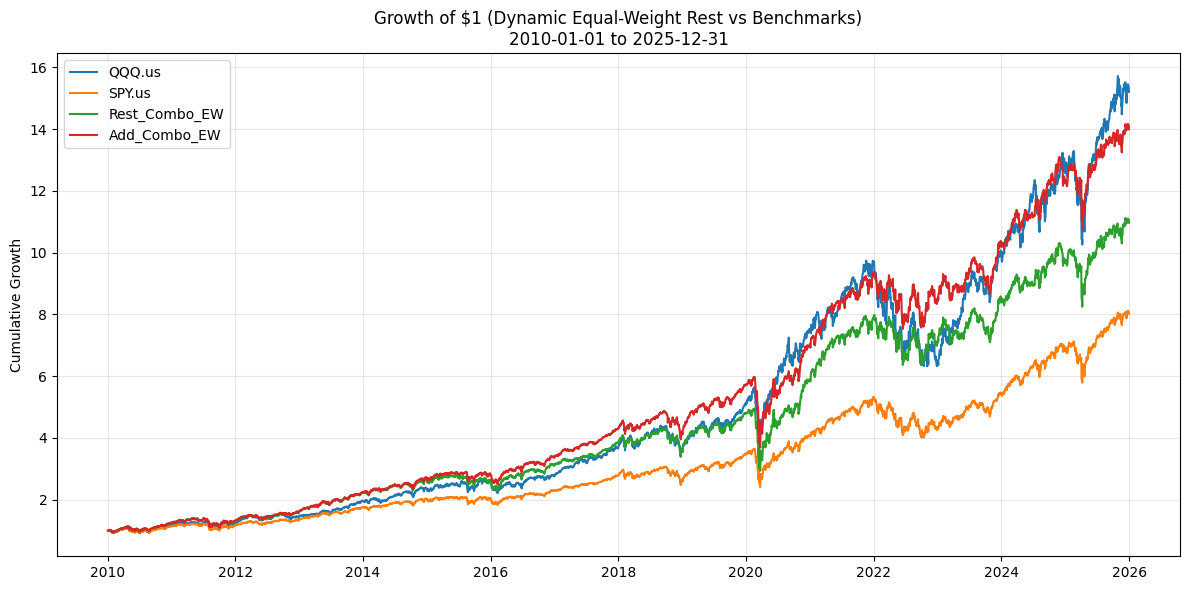

In [0]:
cum_df = compute_cumulative_returns_dynamic_rest(universe_ticker_price2, start_date='2010-01-01', end_date='2025-12-31')

QQQ.us
SPY.us
Rest_Combo_EW


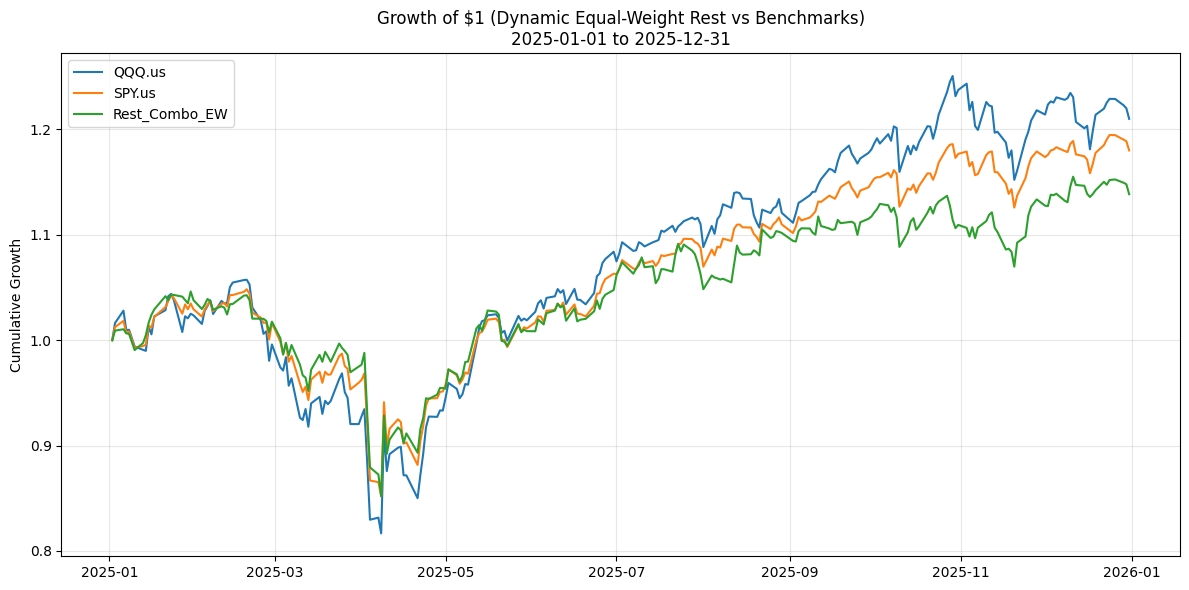

In [0]:
cum_df = compute_cumulative_returns_dynamic_rest(universe_ticker_price2, start_date='2025-01-01', end_date='2025-12-31')

In [0]:
cum_df

In [0]:
# import matplotlib.colors as mcolors
plt.figure(figsize=(12, 6))
# Plot only the columns that exist
plot_cols = ["QQQ.us", "SPY.us",  "Rest_Combo_EW"]
for col in plot_cols:
    print(col)
    plt.plot(cum_df.index, cum_df[col])

plt.title(f"Growth of $1 (Dynamic Equal-Weight Rest vs Benchmarks)\n")
plt.ylabel("Cumulative Growth")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [0]:
cum_df2 = compute_cumulative_returns_dynamic_rest(universe_ticker_price2, start_date='2010-01-01', end_date='2011-04-01')

In [0]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from typing import Sequence, Optional

# # -----------------------------
# # 1) Pivot long -> wide prices
# # -----------------------------
# def pivot_prices_wide(
#     df: pd.DataFrame,
#     date_col: str = "date",
#     ticker_col: str = "symbol",
#     price_col: str = "adjusted_close",
#     tickers_filter: Optional[Sequence[str]] = None,
#     start_date: Optional[str] = None,
#     end_date: Optional[str] = None,
# ) -> pd.DataFrame:
#     """
#     Pivot long-format prices into wide: index=date, columns=ticker, values=price.
#     Supports filtering by tickers and date range before pivot.
#     """
#     x = df[[date_col, ticker_col, price_col]].copy()
#     # Robust date parsing; normalize to midnight (avoid time parts)
#     x[date_col] = pd.to_datetime(x[date_col], errors="coerce").dt.normalize()
#     x = x.dropna(subset=[date_col, price_col])

#     if start_date or end_date:
#         start_ts = pd.to_datetime(start_date) if start_date else x[date_col].min()
#         end_ts   = pd.to_datetime(end_date)   if end_date   else x[date_col].max()
#         x = x[(x[date_col] >= start_ts) & (x[date_col] <= end_ts)]

#     if tickers_filter:
#         x = x[x[ticker_col].isin(tickers_filter)]

#     prices = (
#         x.pivot(index=date_col, columns=ticker_col, values=price_col)
#          .sort_index()
#     )
#     return prices


# # -----------------------------------
# # 2) Returns + spike detection (wide)
# # -----------------------------------
# def _compute_returns_wide(prices: pd.DataFrame, use_log_returns: bool = True) -> pd.DataFrame:
#     """
#     Compute daily returns per column (ticker) in wide matrix.
#     First valid return per ticker is set to 0 to avoid an artificial NaN spike.
#     """
#     if use_log_returns:
#         ret = np.log(prices / prices.shift(1))
#     else:
#         ret = prices.pct_change()

#     # Set the first valid return per ticker to 0
#     for c in ret.columns:
#         idx = ret[c].first_valid_index()
#         if idx is not None and pd.isna(ret.at[idx, c]):
#             ret.at[idx, c] = 0.0
#     return ret


# def detect_spikes_wide(
#     prices: pd.DataFrame,
#     window: int = 20,
#     z_threshold: float = 3.0,
#     mad_threshold: float = 4.0,
#     abs_ret_threshold: Optional[float] = 2,
#     use_log_returns: bool = True,
#     min_history: int = 10,
#     tickers_filter: Optional[Sequence[str]] = None,
#     start_date: Optional[str] = None,
#     end_date: Optional[str] = None,
# ) -> pd.DataFrame:
#     """
#     Detect spike events from a wide price matrix. Returns a tidy (long) DataFrame:
#       ['date', 'ticker', 'ret', 'zscore', 'madscore', 'spike_z', 'spike_mad', 'spike_abs', 'is_spike'].

#     - Rolling mean/std/median/MAD use 'window' and are shifted by 1 day to avoid look-ahead.
#     - A day is flagged as spike if any of (z, mad, abs threshold) fires AND there is enough prior history.
#     - You can filter the output by tickers and date range via args.
#     """
#     returns = _compute_returns_wide(prices, use_log_returns=use_log_returns)

#     # Rolling stats (prior-only)
#     mu  = returns.rolling(window, min_periods=min_history).mean().shift(1)
#     std = returns.rolling(window, min_periods=min_history).std(ddof=0).shift(1)

#     med = returns.rolling(window, min_periods=min_history).median().shift(1)
#     mad = returns.rolling(window, min_periods=min_history).apply(
#         lambda x: np.median(np.abs(x - np.median(x))), raw=True
#     ).shift(1)

#     eps = 1e-12
#     zscore   = (returns - mu) / std.clip(lower=eps)
#     mad_sigma = mad * 1.4826  # convert MAD to sigma-equivalent
#     madscore = (returns - med) / mad_sigma.clip(lower=eps)

#     spike_z   = zscore.abs() >= z_threshold
#     spike_mad = madscore.abs() >= mad_threshold
#     spike_abs = returns.abs() >= (abs_ret_threshold if abs_ret_threshold is not None else np.inf)

#     enough_hist = mu.notna() & med.notna()
#     is_spike = (spike_z | spike_mad) & enough_hist & spike_abs

#     # Stack to long for clean output
#     long_idx = is_spike.stack()
#     idx_true = long_idx[long_idx].index  # MultiIndex (date, ticker)

#     out = pd.DataFrame(idx_true.tolist(), columns=["date", "ticker"])
#     out["ret"]      = returns.stack().loc[idx_true].values
#     out["zscore"]   = zscore.stack().loc[idx_true].values
#     out["madscore"] = madscore.stack().loc[idx_true].values
#     out["spike_z"]  = spike_z.stack().loc[idx_true].values
#     out["spike_mad"]= spike_mad.stack().loc[idx_true].values
#     out["spike_abs"]= spike_abs.stack().loc[idx_true].values
#     out["is_spike"] = True

#     # Optional filtering of spike events (post-detection)
#     if tickers_filter:
#         out = out[out["ticker"].isin(tickers_filter)]
#     if start_date or end_date:
#         start_ts = pd.to_datetime(start_date) if start_date else out["date"].min()
#         end_ts   = pd.to_datetime(end_date)   if end_date   else out["date"].max()
#         out = out[(out["date"] >= start_ts) & (out["date"] <= end_ts)]

#     return out.sort_values(["date", "ticker"]).reset_index(drop=True)


# # ----------------------------------------
# # 3) Convenience: run end-to-end pipeline
# # ----------------------------------------
# def find_price_spikes_from_long(
#     df_long: pd.DataFrame,
#     start_date: str = "2010-01-01",
#     end_date: str   = "2025-12-31",
#     tickers_filter: Optional[Sequence[str]] = None,
#     window: int = 20,
#     z_threshold: float = 3.0,
#     mad_threshold: float = 4.0,
#     abs_ret_threshold: Optional[float] = 2,
#     use_log_returns: bool = True,
#     min_history: int = 10,
#     date_col: str = "date",
#     ticker_col: str = "symbol",
#     price_col: str = "adjusted_close",
# ) -> pd.DataFrame:
#     """
#     One-call helper:
#       - pivots long -> wide (with filters),
#       - detects spikes in the wide matrix,
#       - returns a tidy (long) spike events DataFrame.
#     """
#     prices_wide = pivot_prices_wide(
#         df_long,
#         date_col=date_col,
#         ticker_col=ticker_col,
#         price_col=price_col,
#         tickers_filter=tickers_filter,
#         start_date=start_date,
#         end_date=end_date,
#     )

#     spikes = detect_spikes_wide(
#         prices_wide,
#         window=window,
#         z_threshold=z_threshold,
#         mad_threshold=mad_threshold,
#         abs_ret_threshold=abs_ret_threshold,
#         use_log_returns=use_log_returns,
#         min_history=min_history,
#         tickers_filter=tickers_filter,
#         start_date=start_date,
#         end_date=end_date,
#     )

#     return spikes


# # -------------------------
# # 4) Optional visualization
# # -------------------------
# def plot_ticker_spikes(
#     df_long: pd.DataFrame,
#     spikes_df: pd.DataFrame,
#     ticker: str,
#     date_col: str = "date",
#     ticker_col: str = "symbol",
#     price_col: str = "adjusted_close",
#     start_date: Optional[str] = None,
#     end_date: Optional[str] = None,
# ):
#     """
#     Plot price series and mark spike dates for a single ticker.
#     """
#     sub = df_long[df_long[ticker_col] == ticker].copy()
#     sub[date_col] = pd.to_datetime(sub[date_col], errors="coerce").dt.normalize()
#     sub = sub.dropna(subset=[date_col, price_col]).sort_values(date_col)

#     if start_date or end_date:
#         start_ts = pd.to_datetime(start_date) if start_date else sub[date_col].min()
#         end_ts   = pd.to_datetime(end_date)   if end_date   else sub[date_col].max()
#         sub = sub[(sub[date_col] >= start_ts) & (sub[date_col] <= end_ts)]

#     s = spikes_df[spikes_df["ticker"] == ticker]
#     s_dates = pd.to_datetime(s["date"]).dt.normalize()

#     plt.figure(figsize=(11, 5))
#     plt.plot(sub[date_col], sub[price_col], label=ticker)
#     # Align spikes to available price index
#     price_series = sub.set_index(date_col)[price_col]
#     spike_prices = price_series.reindex(s_dates, method=None)
#     plt.scatter(spike_prices.index, spike_prices.values, color="red", s=25, label="spike")
#     plt.title(f"Price & Spikes: {ticker}")
#     plt.ylabel("Adjusted Close")
#     plt.grid(True, alpha=0.3)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()


In [0]:

# # Suppose your DataFrame `df` has long format: columns ['date','ticker','adjusted_close']
# df = universe_ticker_price
# # (A) Find spikes for selected tickers and date range
# # tickers_of_interest = ["AAPL.us", "MSFT.us", "TSLA.us"]  # edit as needed
# tickers_of_interest = df['symbol'].unique().tolist()
# spikes = find_price_spikes_from_long(
#     df_long=df,
#     start_date="2010-01-01",
#     end_date="2025-12-31",
#     tickers_filter=tickers_of_interest,  # or None for all tickers
#     window=20,
#     z_threshold=3.0,
#     mad_threshold=4.0,
#     abs_ret_threshold=2,  # set None to disable absolute rule
#     use_log_returns=True,
#     min_history=10,
# )

# print(spikes.head(20))

# # Save spikes (headers, no index)
# spikes.to_csv("price_spikes_selected.csv", index=False)

# # (B) Visualize spikes for one ticker
# plot_ticker_spikes(df_long=df, spikes_df=spikes, ticker="TSLA.us",
#                    start_date="2015-01-01", end_date="2025-12-31")


In [0]:
# spikes.head()

In [0]:
# universe_ticker_price = remove_outlier_spikes(universe_ticker_price)

In [0]:
# universe_ticker_price['date']